<a href="https://colab.research.google.com/github/JoseAlberto88/Predictive-Analytics-/blob/main/01_Data_preprocessing_activity_week2_DAMO510_Starter_framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAMO510 - Module 2 In-Class Activity
## Data Preprocessing and Cleaning

### Purpose
In this activity, you will prepare a simulated student-placement dataset for later predictive modelling.

You will:

1. load and inspect the dataset;
2. identify column roles and data types;
3. detect and remove duplicate records;
4. assess missing values;
5. examine numerical distributions;
6. select and justify imputation methods;
7. detect possible outliers;
8. select and justify an outlier-treatment strategy;
9. validate and export the cleaned dataset.



## Submission expectations

Your completed notebook should contain:

- executable Python code;
- visible outputs;
- short written interpretations after each major step;
- justification for each imputation and outlier decision;
- the exported file `student_placement_data_cleaned.csv`;
- answers to all reflection questions.

Run the notebook from top to bottom before submission.

## 0. Import the required libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

## 1. Load the dataset

The dataset file is named `student_placement_data.csv`.

Complete the code below so that it:

- defines the input filename;
- checks whether the file exists;
- loads the file into a DataFrame named `df`;
- displays the first five rows.

### Checkpoint
Your output should show **10 columns**.

In [3]:
# This is the command that we need to create a new folder in Colab.
# I will put all the jupyter notebooks from the course here
import os
os.makedirs("python", exist_ok=True)


In [5]:
# Creating a new folder to save all the data needed.
os.makedirs("data", exist_ok=True)

In [6]:
# TODO 1: Define the file path.
DATA_FILE = Path("data/student_placement_data.csv")

# This check produces a clear error if the file is not in the notebook folder.
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_FILE}. "
        "Place the CSV file in the same folder as this notebook."
    )

# TODO 2: Load the CSV file into a DataFrame named df.
df = pd.read_csv(DATA_FILE)

# TODO 3: Display the first five rows.
df.head(5)

,StudentID,Gender,MathScore,ReadingScore,WritingScore,AttendanceRate,HoursStudied,ParentalEducation,TestPreparationCourse,PlacementScore
0,S0016,Male,79.69,NaN,65.71,105.84,5.95,High School,Completed,66.59
1,S0010,Female,64.98,141.12,73.35,92.86,2.76,PhD,Completed,90.33
2,S0101,Male,70.13,12.67,42.91,102.58,3.62,Bachelor,NaN,44.73
3,S0133,Male,75.15,58.10,72.59,86.95,6.10,PhD,Completed,69.27
4,S0069,Female,72.60,40.46,40.02,88.83,8.27,Bachelor,Completed,53.18


### 1.1 Inspect the dataset structure

In [7]:
# Display the number of rows and columns.
print("Dataset shape:", df.shape)

# Review column names, non-null counts, and data types.
df.info()

# Display descriptive statistics for numerical and categorical variables.
display(df.describe(include="all").T)

Dataset shape: (205, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   StudentID              205 non-null    object 
 1   Gender                 205 non-null    object 
 2   MathScore              190 non-null    float64
 3   ReadingScore           194 non-null    float64
 4   WritingScore           205 non-null    float64
 5   AttendanceRate         205 non-null    float64
 6   HoursStudied           205 non-null    float64
 7   ParentalEducation      205 non-null    object 
 8   TestPreparationCourse  107 non-null    object 
 9   PlacementScore         205 non-null    float64
dtypes: float64(6), object(4)
memory usage: 16.1+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
StudentID,205,200,S0016,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,205,2,Male,103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MathScore,190.00,NaN,NaN,NaN,69.91,10.12,37.59,62.20,70.66,76.12,108.53
ReadingScore,194.00,NaN,NaN,NaN,48.76,47.05,0.13,15.87,36.64,66.83,294.91
WritingScore,205.00,NaN,NaN,NaN,66.34,14.86,32.64,58.09,64.61,73.35,137.19
AttendanceRate,205.00,NaN,NaN,NaN,89.98,8.17,46.38,87.13,90.54,94.30,105.84
HoursStudied,205.00,NaN,NaN,NaN,5.10,2.11,-0.79,3.65,5.10,6.52,10.16
ParentalEducation,205,4,Bachelor,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TestPreparationCourse,107,1,Completed,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PlacementScore,205.00,NaN,NaN,NaN,62.52,15.39,38.59,52.92,58.85,68.85,143.31


### 1.2 Classify the variables

Complete the table in a new Markdown cell below.

| Column | Pandas data type | Analytical role | Description |
|---|---|---|---|
| `StudentID` | Object | Identifier |  |
| `Gender` | Object | Categorical predictor |  |
| `MathScore` | Float64 | Numerical predictor |  |
| `ReadingScore` | Float64 | Numerical predictor |  |
| `WritingScore` | Float64 | Numerical predictor |  |
| `AttendanceRate` | Float64 | Numerical predictor |  |
| `HoursStudied` | Float64 | Numerical predictor |  |
| `ParentalEducation` |Object  | Categorical predictor |  |
| `TestPreparationCourse` | Object | Categorical predictor |  |
| `PlacementScore` | Float64 | Target variable |  |

### Questions
1. Why should `StudentID` not be treated as a numerical predictor?
2. Which variable is the future prediction target?

**Write your answers here:**

1. `StudentId` should not be treated as a numerical predictor since it's only a identifier (the primary key of the dataset)  
2. The variable is called `PlacementScore` which is a continuous variable.

## 2. Detect and remove duplicate records

Duplicate rows can overrepresent certain observations and distort summary statistics.

Complete the code below to:

1. count exact duplicate rows;
2. display duplicate records;
3. remove duplicates;
4. reset the DataFrame index;
5. confirm the new shape.

In [ ]:
# Preserve the initial row count for the final cleaning summary.
initial_rows = len(df)

# TODO 4: Count exact duplicate rows.
duplicate_count = df.duplicated().sum()

print(f"Exact duplicate rows found: {duplicate_count}")

# TODO 5: Display duplicate rows, including all copies.
duplicate_rows = df[df.duplicated(keep=False)]
display(duplicate_rows)

# TODO 6: Remove exact duplicates and reset the index.
df = (
    df.drop_duplicates(keep='last')
      .reset_index(drop=True)
)

print("Shape after duplicate removal:", df.shape)

Exact duplicate rows found: 5


,StudentID,Gender,MathScore,ReadingScore,WritingScore,AttendanceRate,HoursStudied,ParentalEducation,TestPreparationCourse,PlacementScore
0,S0016,Male,79.69,NaN,65.71,105.84,5.95,High School,Completed,66.59
5,S0096,Female,61.84,26.52,70.67,94.30,0.69,Master,NaN,53.89
23,S0031,Male,88.86,3.92,79.95,94.54,7.06,High School,NaN,60.71
33,S0031,Male,88.86,3.92,79.95,94.54,7.06,High School,NaN,60.71
58,S0129,Female,56.22,63.74,57.48,90.81,3.02,Bachelor,NaN,58.85
82,S0096,Female,61.84,26.52,70.67,94.30,0.69,Master,NaN,53.89
121,S0159,Male,91.44,20.58,65.34,93.25,4.41,PhD,Completed,62.35
137,S0159,Male,91.44,20.58,65.34,93.25,4.41,PhD,Completed,62.35
172,S0016,Male,79.69,NaN,65.71,105.84,5.95,High School,Completed,66.59
196,S0129,Female,56.22,63.74,57.48,90.81,3.02,Bachelor,NaN,58.85


Shape after duplicate removal: (200, 10)


### Interpretation

Write 2 to 3 sentences explaining:

- how many duplicate records were detected;
- how many rows remained;
- why duplicate removal should occur before imputation and outlier analysis.

**Write your interpretation here:**

1. We have a total of 5 duplicates in the data.
2. The total rows remained is 200 (before we had 205 in total)
3. We should remove duplicates because they can inflate counts, distort statistics, break models, and create misleading conlcusions.

## 3. Assess missing values

Report both the number and percentage of missing values in each column.

In [ ]:
# TODO 7: Build a missing-value summary table.
missing_summary = pd.DataFrame({
    "MissingCount": df.isna().sum(),
    "MissingPercent": df.isna().mean() * 100
})

# Sort from the highest to the lowest missing percentage.
missing_summary = missing_summary.sort_values(
    "MissingPercent",
    ascending=False
)

display(missing_summary)

,MissingCount,MissingPercent
TestPreparationCourse,95,47.50
MathScore,15,7.50
ReadingScore,10,5.00
StudentID,0,0.00
Gender,0,0.00
WritingScore,0,0.00
AttendanceRate,0,0.00
HoursStudied,0,0.00
ParentalEducation,0,0.00
PlacementScore,0,0.00


### Missing-value interpretation

For each variable with missing values, consider:

- Is the variable numerical or categorical?
- Does a blank value mean “unknown,” or could it represent a meaningful category?
- Would mean, median, mode, group-based imputation, or recoding be appropriate?
- What evidence is required before deciding?

Do **not** impute yet. First examine the relevant distributions and categories.

**Write your initial observations here:**

1. For the observations above, we have a total of three variables with missing values `TestPreparationCourse`, `MathScore` and `ReadingScore`.
2. `TestPreparationCourse` is a categorical variable and the rest variables are continuous.
3. For the categorical variable, maybe a blank value means "unknown", however, we need to check carefully how to "fill" the null values for `TestPreparationCourse`
4. It depends on the type of distribution, so we need to check later the skewness.
5. The evidence that we need is to create some visualizations or create the appropiate code to clearly check the skewness.

## 4. Examine variables with missing values

### 4.1 Identify the affected columns automatically

In [ ]:
# TODO 8: Create a list of columns containing at least one missing value.
missing_cols = df.columns[df.isna().sum() > 0].tolist()

print("Columns containing missing values:", missing_cols)

Columns containing missing values: ['MathScore', 'ReadingScore', 'TestPreparationCourse']


### 4.2 Examine numerical distributions

For numerical columns with missing values, use:

- summary statistics;
- skewness;
- a histogram;
- a boxplot.

Complete the reusable function below.

In [ ]:
def plot_numeric_distribution(data, column, bins=20):
    """Display descriptive statistics, skewness, histogram, and boxplot."""

    valid_values = data[column].dropna()

    print(f"Column: {column}")
    print(f"Non-missing observations: {len(valid_values)}")
    print(f"Missing observations: {data[column].isna().sum()}")
    print(f"Mean: {valid_values.mean():.2f}")
    print(f"Median: {valid_values.median():.2f}")
    print(f"Skewness: {valid_values.skew():.2f}")

    # TODO 9: Create a histogram.
    plt.figure(figsize=(7, 4))
    plt.hist(
        valid_values,
        bins=bins,
        edgecolor="black"
    )
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

    # TODO 10: Create a horizontal boxplot.
    plt.figure(figsize=(7, 2.5))
    plt.boxplot(valid_values, vert=False)
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.show()

Column: MathScore
Non-missing observations: 185
Missing observations: 15
Mean: 69.75
Median: 70.64
Skewness: 0.28


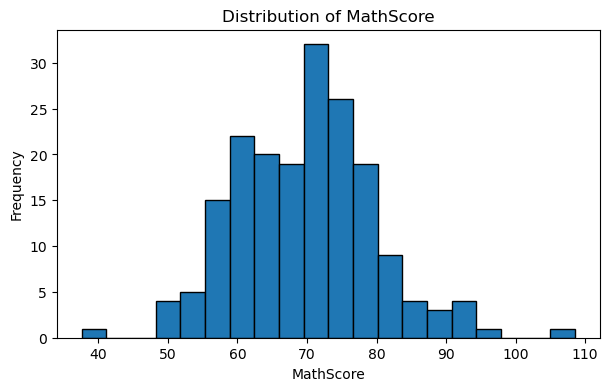

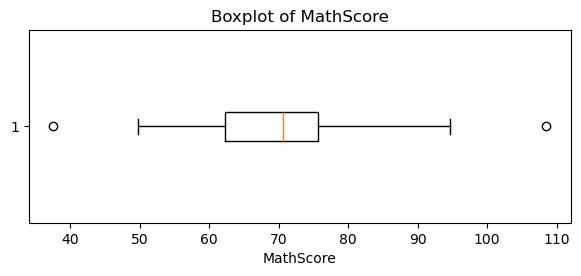

Column: ReadingScore
Non-missing observations: 190
Missing observations: 10
Mean: 49.18
Median: 37.48
Skewness: 1.88


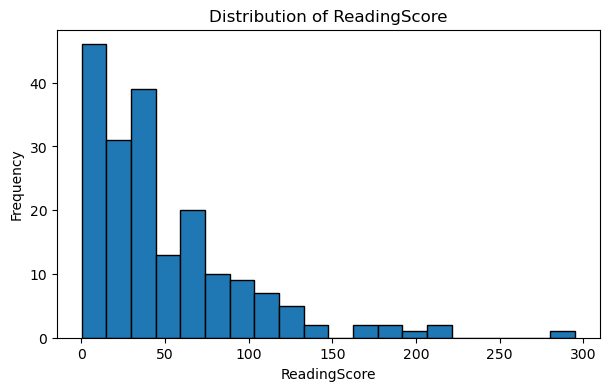

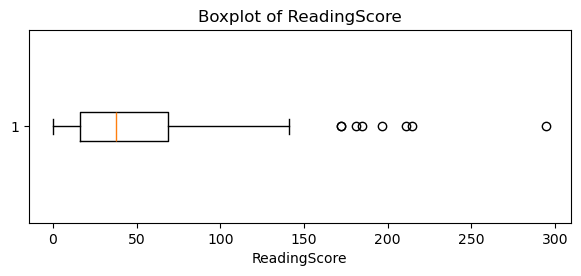

In [ ]:
# Identify numerical columns that contain missing values.
numeric_missing_cols = [
    column for column in missing_cols
    if pd.api.types.is_numeric_dtype(df[column])
]

for column in numeric_missing_cols:
    plot_numeric_distribution(df, column)

### 4.3 Examine categorical variables with missing values

In [ ]:
categorical_missing_cols = [
    column for column in missing_cols
    if not pd.api.types.is_numeric_dtype(df[column])
]

for column in categorical_missing_cols:
    print(f"\nColumn: {column}")

    # TODO 11: Display counts, including missing values.
    display(df[column].value_counts(dropna=False))


Column: TestPreparationCourse


TestPreparationCourse
Completed    105
NaN           95
Name: count, dtype: int64

### Distribution decision table

Complete this table before imputing.

| Variable | Missing count | Distribution/category pattern | Proposed treatment | Justification |
|---|---:|---|---|---|
|`MathScore`|15|Mean = 69.75, Median = 70.64, Skewness = 0.28 (≈ symmetric)|Impute with mean|Distribution is nearly symmetric, mean is a stable estimator. Missing rate is small (≈7.5%), so mean imputation will not distort the distribution.|
| `ReadingScore` | 10 |Mean = 49.18, Median = 37.48, Skewness = 1.88 (strong right skew)  |Impute with median  | Strong skewness means mean is not representative. Median is robust to outliers and preserves the distribution shape. |
| `TestPreparationCourse` | 95  | Categories: Completed (105), NaN (95) |Convert NaN to "Not Completed"  | Missingness is structured and meaningful. NaN likely represents students who did not take the course. Converting NaN to “Not Completed” preserves the true categorical meaning and avoids bias. |


Consider whether grouping by `Gender` is analytically reasonable. Compare group-level statistics before deciding.

In [ ]:
# Optional diagnostic: compare numerical variables by Gender.
for column in numeric_missing_cols:
    print(f"\n{column} by Gender")
    display(
        df.groupby("Gender")[column]
          .agg(["count", "mean", "median", "std"])
    )


MathScore by Gender


,count,mean,median,std
Gender,,,,
Female,86,68.85,69.22,9.25
Male,99,70.54,70.92,10.48



ReadingScore by Gender


,count,mean,median,std
Gender,,,,
Female,95,53.74,39.78,49.60
Male,95,44.63,32.70,44.77


## 5. Impute missing values

Implement the treatment choices you justified above.

### Guidance

- The **mean** is more appropriate for approximately symmetric distributions without influential extremes.
- The **median** is more robust for skewed distributions.
- Group-based imputation may preserve subgroup differences, but only when the grouping variable is meaningful.
- For categorical variables, determine whether a blank is truly missing or represents a meaningful category.
- Include a fallback value in case an entire group is missing.

In [ ]:
# Work on a copy so that the pre-imputation data remains available for comparison.
df_imputed = df.copy()

# TODO 12: Impute MathScore using your selected method.
# Example structure:
# group_statistic = df_imputed.groupby("Gender")["MathScore"].transform("mean")
# df_imputed["MathScore"] = df_imputed["MathScore"].fillna(group_statistic)
df_imputed["MathScore"] = df_imputed["MathScore"].fillna(
     df_imputed["MathScore"].mean()
)
# )


# TODO 13: Impute ReadingScore using your selected method.

df_imputed["ReadingScore"] = df_imputed["ReadingScore"].fillna(
    df_imputed["ReadingScore"].median()
)
# TODO 14: Treat missing values in TestPreparationCourse.

df_imputed["TestPreparationCourse"] = df_imputed["TestPreparationCourse"].fillna("Not Completed")

# Check the results.
post_imputation_missing = df_imputed.isna().sum()

print("Missing values after imputation:")
print(post_imputation_missing[post_imputation_missing > 0])

Missing values after imputation:
Series([], dtype: int64)


### 5.1 Validate and compare the imputation

Do not assume the code worked correctly. Verify it.

In [ ]:
# TODO 15: Confirm that no missing values remain.
assert post_imputation_missing.sum() == 0, "Missing values remain after imputation."

# Compare relevant statistics before and after imputation.
for column in numeric_missing_cols:
    comparison = pd.DataFrame({
        "Before": df[column].describe(),
        "After": df_imputed[column].describe()
    })

    print(f"\nComparison for {column}")
    display(comparison)


Comparison for MathScore


,Before,After
count,185.00,200.00
mean,69.75,69.75
std,9.94,9.56
min,37.59,37.59
25%,62.27,62.86
50%,70.64,69.75
75%,75.61,75.14
max,108.53,108.53



Comparison for ReadingScore


,Before,After
count,190.00,200.00
mean,49.18,48.60
std,47.34,46.21
min,0.13,0.13
25%,15.87,17.37
50%,37.48,37.48
75%,68.64,66.67
max,294.91,294.91


### Imputation interpretation

For each imputed variable, explain:

1. the method used;
2. the statistical or contextual reason;
3. whether the distribution changed substantially after imputation;
4. one limitation of the selected method.

**Write your interpretation here:**

1. For the variable `MathScore`, we decided to fill missing values with the mean because the data is nearly simmetric. For the `ReadingScore`, we decided to fill missing values with mean because the data is strong skewness.
2. The statistical reason was to analize if the data is normally or skewness and apply the corresponding method.
3. For the variable `Mathscore`, we have the same mean, but we increse a litte the standard distribution a little. For the another variable, we changed a little both the mean and the standard for the `ReadingScore`.
4. If we select to fill missing values with mean, we reduce the standard deviation as a result the data looks more "stable". For the mean, the tail becomes shorter.

## 6. Examine all numerical variables for possible outliers

Exclude identifiers such as `StudentID`.

A flagged value is a **potential outlier**, not automatically an error.

In [ ]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   StudentID              200 non-null    object 
 1   Gender                 200 non-null    object 
 2   MathScore              200 non-null    float64
 3   ReadingScore           200 non-null    float64
 4   WritingScore           200 non-null    float64
 5   AttendanceRate         200 non-null    float64
 6   HoursStudied           200 non-null    float64
 7   ParentalEducation      200 non-null    object 
 8   TestPreparationCourse  200 non-null    object 
 9   PlacementScore         200 non-null    float64
dtypes: float64(6), object(4)
memory usage: 15.8+ KB


Numerical variables for outlier analysis: ['MathScore', 'ReadingScore', 'WritingScore', 'AttendanceRate', 'HoursStudied', 'PlacementScore']
Column: MathScore
Non-missing observations: 200
Missing observations: 0
Mean: 69.75
Median: 69.75
Skewness: 0.29


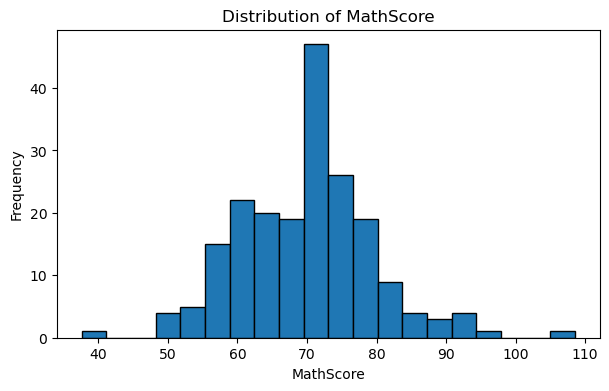

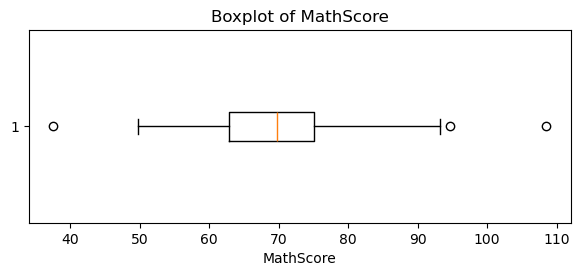

Column: ReadingScore
Non-missing observations: 200
Missing observations: 0
Mean: 48.60
Median: 37.48
Skewness: 1.95


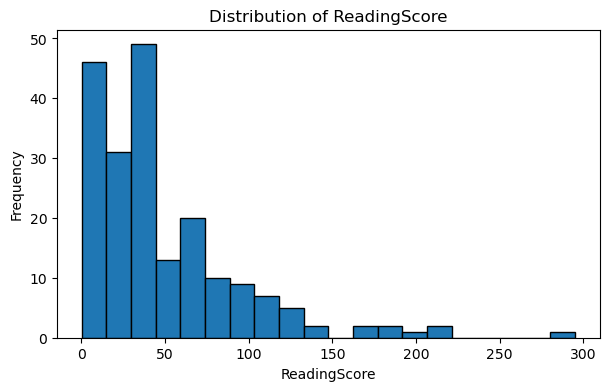

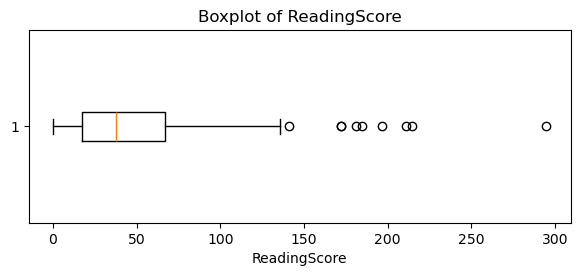

Column: WritingScore
Non-missing observations: 200
Missing observations: 0
Mean: 66.31
Median: 64.58
Skewness: 1.45


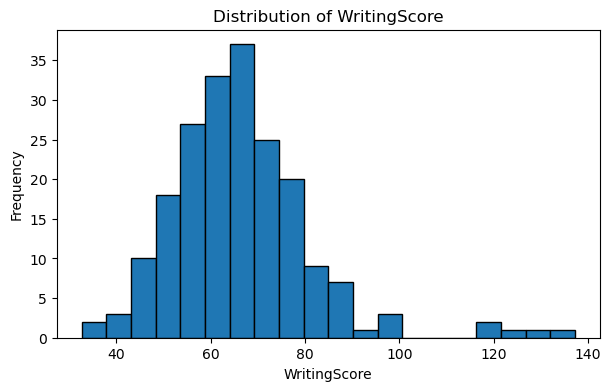

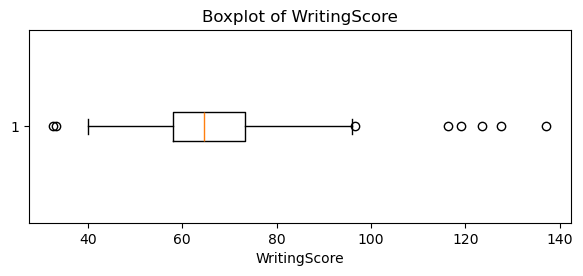

Column: AttendanceRate
Non-missing observations: 200
Missing observations: 0
Mean: 89.83
Median: 90.21
Skewness: -2.61


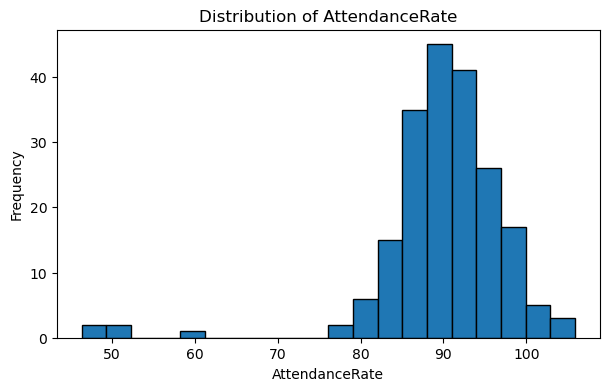

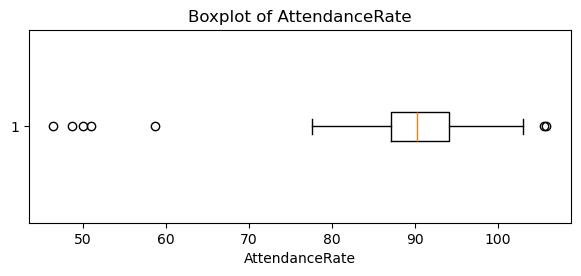

Column: HoursStudied
Non-missing observations: 200
Missing observations: 0
Mean: 5.12
Median: 5.10
Skewness: -0.04


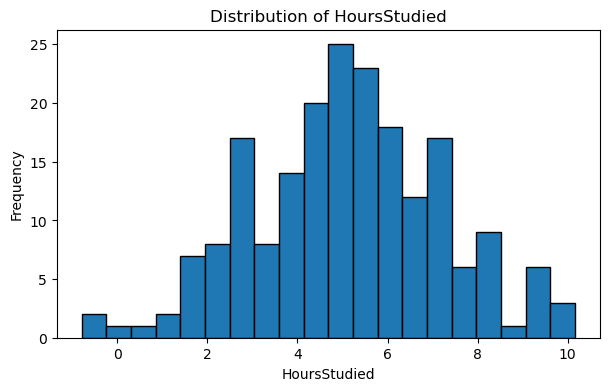

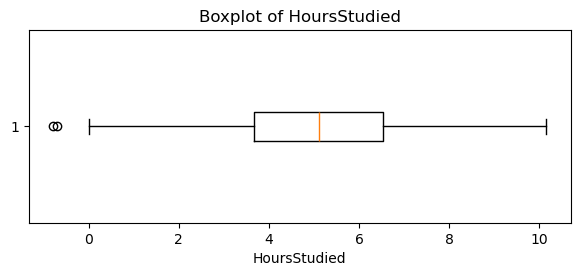

Column: PlacementScore
Non-missing observations: 200
Missing observations: 0
Mean: 62.57
Median: 58.77
Skewness: 1.73


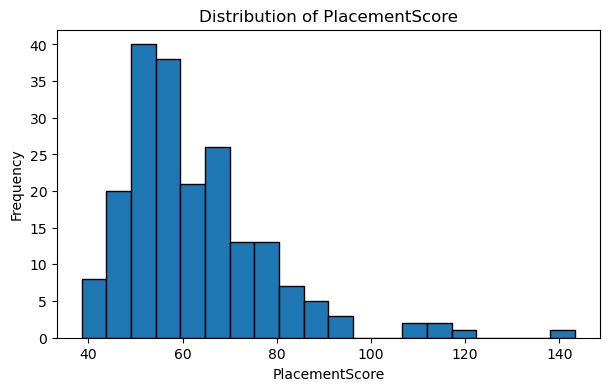

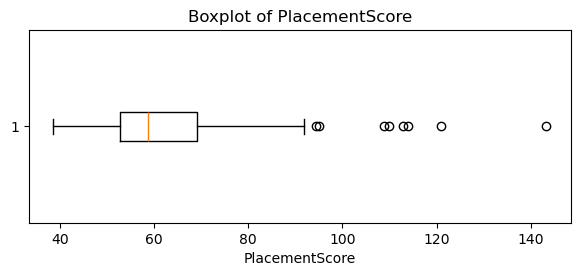

In [ ]:
# TODO 16: Select numerical variables and exclude StudentID.
numeric_cols = (
    df_imputed
    .select_dtypes(include=np.number)
    .columns
    #.drop("StudentID")
    .tolist()
)

print("Numerical variables for outlier analysis:", numeric_cols)

for column in numeric_cols:
    plot_numeric_distribution(df_imputed, column)

## 7. Detect potential outliers

Use the following instructional rule:

- `|skewness| < 0.5`: approximately symmetric --> Z-score;
- `0.5 <= |skewness| < 1`: moderately skewed --> IQR;
- `|skewness| >= 1`: highly skewed --> IQR.

This rule guides method selection, but domain knowledge is still required.

In [ ]:
def choose_outlier_method(skewness):
    """Return the method, threshold, and distribution classification."""

    absolute_skewness = abs(skewness)

    if absolute_skewness < 0.5:
        return "Z-score", 3.0, "Approximately symmetric"
    elif absolute_skewness < 1:
        return "IQR", 1.5, "Moderately skewed"
    else:
        return "IQR", 1.5, "Highly skewed"


def detect_outliers(series):
    """Detect outliers in a numerical Series and return details."""

    valid_values = series.dropna()
    skewness = valid_values.skew()
    method, threshold, distribution = choose_outlier_method(skewness)

    lower_bound = np.nan
    upper_bound = np.nan

    if method == "Z-score":
        z_scores = np.abs(stats.zscore(valid_values))
        outlier_indices = valid_values.index[z_scores > threshold]

    else:
        # TODO 17: Calculate Q1, Q3, and IQR.
        q1 = valid_values.quantile(0.25)
        q3 = valid_values.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - threshold * iqr
        upper_bound = q3 + threshold * iqr

        outlier_indices = valid_values[
            (valid_values < lower_bound) |
            (valid_values > upper_bound)
        ].index

    return {
        "Skewness": skewness,
        "Distribution": distribution,
        "Method": method,
        "Threshold": threshold,
        "LowerBound": lower_bound,
        "UpperBound": upper_bound,
        "OutlierIndices": outlier_indices.tolist(),
        "OutlierCount": len(outlier_indices)
    }

In [ ]:
# Apply the function to all selected numerical variables.
outlier_results = {}
outlier_summary_rows = []

for column in numeric_cols:
    result = detect_outliers(df_imputed[column])
    outlier_results[column] = result

    outlier_summary_rows.append({
        "Column": column,
        "Skewness": result["Skewness"],
        "Distribution": result["Distribution"],
        "Method": result["Method"],
        "LowerBound": result["LowerBound"],
        "UpperBound": result["UpperBound"],
        "OutlierCount": result["OutlierCount"]
    })

outlier_summary = pd.DataFrame(outlier_summary_rows)
display(outlier_summary.round(2))

,Column,Skewness,Distribution,Method,LowerBound,UpperBound,OutlierCount
0,MathScore,0.29,Approximately symmetric,Z-score,NaN,NaN,2
1,ReadingScore,1.95,Highly skewed,IQR,-56.58,140.61,9
2,WritingScore,1.45,Highly skewed,IQR,34.91,96.43,8
3,AttendanceRate,-2.61,Highly skewed,IQR,76.56,104.65,7
4,HoursStudied,-0.04,Approximately symmetric,Z-score,NaN,NaN,0
5,PlacementScore,1.73,Highly skewed,IQR,27.87,94.01,8


In [ ]:
# Display the actual flagged observations for contextual review.
for column, result in outlier_results.items():
    indices = result["OutlierIndices"]

    print(f"\n{column}: {len(indices)} potential outlier(s)")

    if indices:
        display(
            df_imputed.loc[
                indices,
                ["StudentID", column]
            ].sort_values(column)
        )


MathScore: 2 potential outlier(s)


,StudentID,MathScore
150,S0187,37.59
138,S0134,108.53



ReadingScore: 9 potential outlier(s)


,StudentID,ReadingScore
0,S0010,141.12
164,S0055,172.06
8,S0192,172.09
20,S0099,180.80
7,S0183,184.58
10,S0066,196.77
192,S0021,210.95
83,S0123,214.36
58,S0178,294.91



WritingScore: 8 potential outlier(s)


,StudentID,WritingScore
97,S0007,32.64
120,S0029,33.19
106,S0116,96.59
55,S0077,116.37
188,S0088,119.17
35,S0046,123.56
89,S0062,127.59
108,S0011,137.19



AttendanceRate: 7 potential outlier(s)


,StudentID,AttendanceRate
16,S0087,46.38
72,S0042,48.66
161,S0172,49.93
153,S0014,50.89
186,S0100,58.60
114,S0185,105.52
167,S0016,105.84



HoursStudied: 0 potential outlier(s)

PlacementScore: 8 potential outlier(s)


,StudentID,PlacementScore
138,S0134,94.32
164,S0055,95.05
20,S0099,108.84
192,S0021,109.90
7,S0183,112.92
10,S0066,113.94
83,S0123,121.02
58,S0178,143.31


### Outlier decision table

Complete this table **before modifying the data**.

| Variable | Method used | Outliers detected | Plausible or impossible? | Selected treatment | Justification |
|---|---|---:|---|---|---|
| `MathScore` | Z‑score |  2|  Plausible (scores typically 0–100)| **Retain** | Both outliers fall within a realistic exam‑score range. Z‑score flagged them due to distance from mean, not because they are invalid. Removing them would distort natural variation. |
| `ReadingScore` | IQR |  9| Mostly plausible, but check extreme highs | **Winsorize (cap at upper bound)** | ReadingScore is highly skewed (1.95). Extreme high values may reflect unusually strong readers or data entry inflation. Winsorizing preserves rank order while preventing extreme leverage.  |
| `WritingScore` | IQR | 8  |Plausible but unusually high  | **Retain or Winsorize (depending on context)** | WritingScore is also skewed (1.45). Outliers are likely real high performers. If the variable is used for modeling, winsorizing reduces undue influence. If used descriptively, retain. |
| `AttendanceRate` | IQR | 7  |Some impossible (e.g., > 100%)  | **Trim impossible values; cap plausible highs** | AttendanceRate should logically be 0–100%. Values above 100% are invalid and must be corrected or removed. Values slightly below 0 or above 100 should be capped at boundaries. |
| `HoursStudied` | Z‑score | 0 | All plausible | **Retain** |  No outliers detected. Distribution is symmetric (skew = −0.04). No action needed. |
| `PlacementScore` | IQR | 8 |Plausible but extreme  | **Winsorize** |PlacementScore is highly skewed (1.73). Outliers likely represent very strong students. Winsorizing prevents these few observations from dominating correlations or regression models.  |

Possible treatments include:

- retain the observations;
- trim clearly erroneous rows;
- cap values using valid boundaries;
- winsorize;
- create a transformed feature;
- investigate the source of the values.

Consider each variable's valid range and analytical role. Be especially cautious with the target variable.

## 8. Handle outliers

Create a new DataFrame called `df_clean`.

Do not delete every statistically flagged observation automatically.

In [ ]:
df_clean = df_imputed.copy()

# TODO 18: Define valid-range checks based on variable meaning.
# Replace or extend these ranges if your activity instructions specify otherwise.
valid_ranges = {
    "MathScore": (0, 100),
    "ReadingScore": (0, 100),
    "WritingScore": (0, 100),
    "AttendanceRate": (0, 100),
    "PlacementScore": (0, 100)
}

invalid_mask = pd.Series(False, index=df_clean.index)

for column, (minimum, maximum) in valid_ranges.items():
    invalid_mask |= ~df_clean[column].between(minimum, maximum)

print("Rows containing impossible bounded values:", invalid_mask.sum())
display(df_clean.loc[invalid_mask])

# TODO 19: Decide whether these rows should be removed, corrected, or retained.
# Example:
df_clean = df_clean.loc[~invalid_mask].copy()


# TODO 20: Apply your justified treatment to other outliers.
# Examples may include:
# - trimming selected rows;
# - retaining plausible extreme observations;
# - creating a transformed feature with np.log1p();
# - creating a reflected transformation for a left-skewed bounded variable.

# --- Winsorize ReadingScore (upper bound only) ---
# Using the IQR-based upper bound you computed earlier: 140.61
reading_upper = 140.61

df_clean["ReadingScore"] = np.where(
    df_clean["ReadingScore"] > reading_upper,
    reading_upper,
    df_clean["ReadingScore"]
)

# --- WritingScore ---
# Impossible values (>100) were already removed in TODO 19.
# Plausible extreme values should be retained.
# No winsorization applied.

# --- MathScore ---
# One impossible value (>100) was removed in TODO 19.
# Remaining outliers are plausible → retain.

# --- AttendanceRate ---
# Impossible values (>100) were removed in TODO 19.
# Remaining values are plausible → retain.

# --- HoursStudied ---
# No outliers detected → retain.

# --- PlacementScore (TARGET VARIABLE) ---
# DO NOT winsorize or modify.
# Retain all plausible values.

Rows containing impossible bounded values: 37


,StudentID,Gender,MathScore,ReadingScore,WritingScore,AttendanceRate,HoursStudied,ParentalEducation,TestPreparationCourse,PlacementScore
0,S0010,Female,64.98,141.12,73.35,92.86,2.76,PhD,Completed,90.33
1,S0101,Male,70.13,12.67,42.91,102.58,3.62,Bachelor,Not Completed,44.73
4,S0160,Female,76.34,114.95,65.36,97.84,7.50,High School,Completed,84.63
7,S0183,Female,74.44,184.58,92.59,94.37,6.14,High School,Not Completed,112.92
8,S0192,Male,55.70,172.09,53.98,98.20,3.46,High School,Not Completed,90.10
9,S0165,Female,62.07,135.67,59.79,98.36,2.62,PhD,Not Completed,83.47
10,S0066,Female,83.07,196.77,72.27,92.46,7.37,PhD,Completed,113.94
12,S0074,Female,72.97,120.66,69.79,98.63,5.66,High School,Not Completed,86.32
20,S0099,Female,72.77,180.80,84.99,92.51,8.28,High School,Not Completed,108.84
22,S0017,Female,62.98,9.01,65.17,101.18,5.15,High School,Not Completed,47.44


### Important target-variable caution

`PlacementScore` is the future prediction target. Removing observations only because the target is unusually high or low may bias the predictive problem. Any target-based row removal requires a strong data-quality justification.

## 9. Validate the cleaned dataset

Complete the checks below.

In [ ]:
# TODO 21: Validate duplicates, missing values, and final shape.
final_duplicate_count = df_clean.duplicated().sum()
final_missing_count = df_clean.isna().sum().sum()

print("Final duplicate count:", final_duplicate_count)
print("Final missing-value count:", final_missing_count)
print("Final dataset shape:", df_clean.shape)

assert final_duplicate_count == 0, "Duplicate rows remain."
assert final_missing_count == 0, "Missing values remain."

Final duplicate count: 0
Final missing-value count: 0
Final dataset shape: (163, 10)


In [ ]:
# Compare row counts across stages.
cleaning_summary = pd.DataFrame({
    "Stage": [
        "Original dataset",
        "After duplicate removal",
        "After imputation",
        "Final cleaned dataset"
    ],
    "Rows": [
        initial_rows,
        len(df),
        len(df_imputed),
        len(df_clean)
    ]
})

display(cleaning_summary)

,Stage,Rows
0,Original dataset,205
1,After duplicate removal,205
2,After imputation,200
3,Final cleaned dataset,163


In [ ]:
# Review final summary statistics.
display(df_clean.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
StudentID,163,163,S0133,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,163,2,Male,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MathScore,163.00,NaN,NaN,NaN,69.83,8.95,49.75,62.89,69.75,75.13,94.63
ReadingScore,163.00,NaN,NaN,NaN,34.82,25.42,0.13,13.63,32.81,46.47,95.13
WritingScore,163.00,NaN,NaN,NaN,64.43,11.29,32.64,57.49,64.32,72.36,96.59
AttendanceRate,163.00,NaN,NaN,NaN,88.91,8.25,46.38,86.88,89.59,93.20,99.88
HoursStudied,163.00,NaN,NaN,NaN,5.15,2.10,-0.70,3.69,5.21,6.53,9.88
ParentalEducation,163,4,Bachelor,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TestPreparationCourse,163,2,Completed,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PlacementScore,163.00,NaN,NaN,NaN,57.92,9.18,38.59,51.97,56.62,64.98,84.89


### Final validation interpretation

Explain:

- how many rows were removed and why;
- whether any variables were transformed;
- whether all missing values and duplicates were resolved;
- whether the cleaned data remain representative of the original dataset;
- any unresolved limitations.

**Write your interpretation here:**

1. The total rows that were removed was 42 and they were removed because they have values that are phisycally impossible like score greater than 100 percent.
2. No, any variable weren't not transformed.
3. Yes, all missing values and duplicates were resolved.
4. The answer is not, we make a lot of changes to make a cleaner data ready for modeling.
5. We need to analyze the target variable carefully if it needs cleaning stuck. But usually not.

## 10. Save the cleaned dataset

Export the final DataFrame as `student_placement_data_cleaned.csv`.

In [ ]:
OUTPUT_FILE = Path("student_placement_data_cleaned.csv")

# TODO 22: Save df_clean without the DataFrame index.
df_clean.to_csv(OUTPUT_FILE, index=False)

print(f"Cleaned dataset saved to: {OUTPUT_FILE.resolve()}")

Cleaned dataset saved to: C:\Users\piuze\Term_2\Predictive_analytics\week_2\student_placement_data_cleaned.csv


## 11. Reflection questions

Answer each question in your own words.

### 1. What are the consequences of ignoring missing values?

**Answer:**


### 2. How can outliers affect descriptive statistics and predictive models?

**Answer:**


### 3. When would transformation be preferable to trimming?

**Answer:**


### 4. Why is it risky to remove observations solely because the target variable is extreme?

**Answer:**


### 5. Which preprocessing decision in this activity required the most judgment? Explain.

**Answer:**

## Final submission checklist

Before submitting, confirm that:

- all TODO items are completed;
- all cells run without errors;
- interpretations and reflection answers are included;
- preprocessing decisions are justified;
- `StudentID` is excluded from outlier analysis;
- duplicate and missing-value checks pass;
- the cleaned CSV file is created;
- the notebook has been restarted and run from top to bottom.